In [1]:
# =============================================================================
# SUPPLY CHAIN OPTIMIZATION — DataCo Global
# Notebook 03: Profitability & Loss Analysis
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH = Path('../data/processed')
IMG_PATH  = Path('../img')

PALETTE = {
    'primary'  : '#1A6FBF',
    'secondary': '#E8622A',
    'accent'   : '#5B4FCF',
    'success'  : '#2A9D5C',
    'warning'  : '#E8A020',
    'neutral'  : '#4A5568',
    'light'    : '#F7F9FC',
    'border'   : '#E2E8F0',
    'text'     : '#1A202C',
    'muted'    : '#718096',
}

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : PALETTE['light'],
    'axes.edgecolor'   : PALETTE['border'],
    'axes.labelcolor'  : PALETTE['text'],
    'axes.titlecolor'  : PALETTE['text'],
    'xtick.color'      : PALETTE['neutral'],
    'ytick.color'      : PALETTE['neutral'],
    'text.color'       : PALETTE['text'],
    'grid.color'       : PALETTE['border'],
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.titleweight' : 'bold',
})

print("✅ Imports and config ready")

✅ Imports and config ready


In [2]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH / 'supply_chain_clean.csv')

print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"\nKey financial metrics:")
print(f"   Total Revenue:    ${df['Sales'].sum():>15,.0f}")
print(f"   Total Profit:     ${df['Order Profit Per Order'].sum():>15,.0f}")
print(f"   Overall Margin:   {df['Order Profit Per Order'].sum() / df['Sales'].sum():>15.1%}")
print(f"   Avg Order Value:  ${df['Sales'].mean():>15.2f}")
print(f"   Avg Profit/Order: ${df['Order Profit Per Order'].mean():>15.2f}")
print(f"   Loss-making orders: {(df['Order Profit Per Order'] < 0).sum():,} "
      f"({(df['Order Profit Per Order'] < 0).mean():.1%})")
print(f"   Suspected fraud:    {(df['Order Status'] == 'SUSPECTED_FRAUD').sum():,} orders")

✅ Data loaded: 180,511 rows × 52 cols

Key financial metrics:
   Total Revenue:    $     36,781,952
   Total Profit:     $      3,966,180
   Overall Margin:             10.8%
   Avg Order Value:  $         203.77
   Avg Profit/Order: $          21.97
   Loss-making orders: 33,782 (18.7%)
   Suspected fraud:    4,062 orders


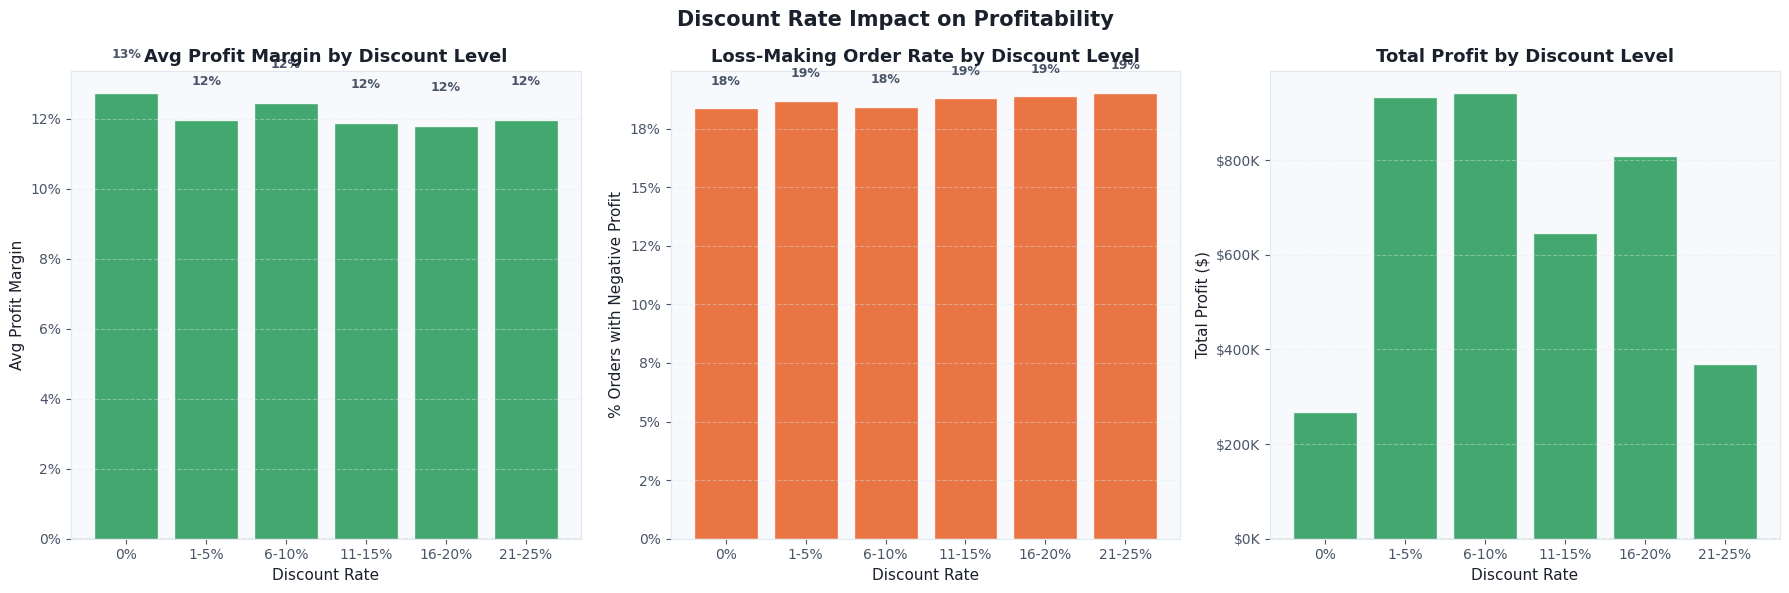

✅ Saved: discount_impact.png

Discount Analysis Summary:
discount_bucket  orders  avg_margin  loss_rate  total_profit
             0%   10028        0.13       0.18     267412.40
           1-5%   40113        0.12       0.19     933131.31
          6-10%   40112        0.12       0.18     942512.00
         11-15%   30085        0.12       0.19     645929.50
         16-20%   40115        0.12       0.19     807985.53
         21-25%   20058        0.12       0.19     369209.46


In [3]:
# ── 2. DISCOUNT IMPACT ANALYSIS ───────────────────────────────────────────────
# Bucket discount rates
df['discount_bucket'] = pd.cut(
    df['Order Item Discount Rate'],
    bins=[-0.01, 0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 1.0],
    labels=['0%', '1-5%', '6-10%', '11-15%', '16-20%', '21-25%', '>25%']
)

discount_analysis = df.groupby('discount_bucket', observed=True).agg(
    orders         = ('Order Id',                'count'),
    avg_margin     = ('Order Item Profit Ratio',  'mean'),
    total_profit   = ('Order Profit Per Order',   'sum'),
    loss_rate      = ('Order Profit Per Order',   lambda x: (x < 0).mean()),
    avg_discount   = ('Order Item Discount Rate', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Discount Rate Impact on Profitability',
             fontsize=15, fontweight='bold', color=PALETTE['text'])

# Avg margin by discount bucket
ax = axes[0]
colors_disc = [PALETTE['success'] if v > 0 else PALETTE['secondary']
               for v in discount_analysis['avg_margin']]
bars = ax.bar(discount_analysis['discount_bucket'], discount_analysis['avg_margin'],
              color=colors_disc, alpha=0.88, edgecolor='white')
ax.set_title('Avg Profit Margin by Discount Level')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Avg Profit Margin')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.axhline(0, color=PALETTE['neutral'], linewidth=1, linestyle='--', alpha=0.6)
for bar, val in zip(bars, discount_analysis['avg_margin']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.04,
            f'{val:.0%}', ha='center', fontsize=9,
            fontweight='bold', color=PALETTE['neutral'])
ax.grid(True, alpha=0.4, axis='y')

# Loss rate by discount bucket
ax = axes[1]
ax.bar(discount_analysis['discount_bucket'], discount_analysis['loss_rate'],
       color=PALETTE['secondary'], alpha=0.88, edgecolor='white')
ax.set_title('Loss-Making Order Rate by Discount Level')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('% Orders with Negative Profit')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
for bar, val in zip(bars, discount_analysis['loss_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.0%}', ha='center', fontsize=9,
            fontweight='bold', color=PALETTE['neutral'])
ax.grid(True, alpha=0.4, axis='y')

# Total profit by discount bucket
ax = axes[2]
colors_tp = [PALETTE['success'] if v > 0 else PALETTE['secondary']
             for v in discount_analysis['total_profit']]
ax.bar(discount_analysis['discount_bucket'], discount_analysis['total_profit'],
       color=colors_tp, alpha=0.88, edgecolor='white')
ax.set_title('Total Profit by Discount Level')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Total Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.axhline(0, color=PALETTE['neutral'], linewidth=1, linestyle='--', alpha=0.6)
ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(IMG_PATH / 'discount_impact.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

print("✅ Saved: discount_impact.png")
print("\nDiscount Analysis Summary:")
print(discount_analysis[['discount_bucket','orders','avg_margin',
                          'loss_rate','total_profit']].to_string(index=False))

Loss-making orders: 33,782 (18.7%)
Total loss amount:  $-3,883,483
Avg loss per order: $-114.96
Max loss per order: $-4,274.98


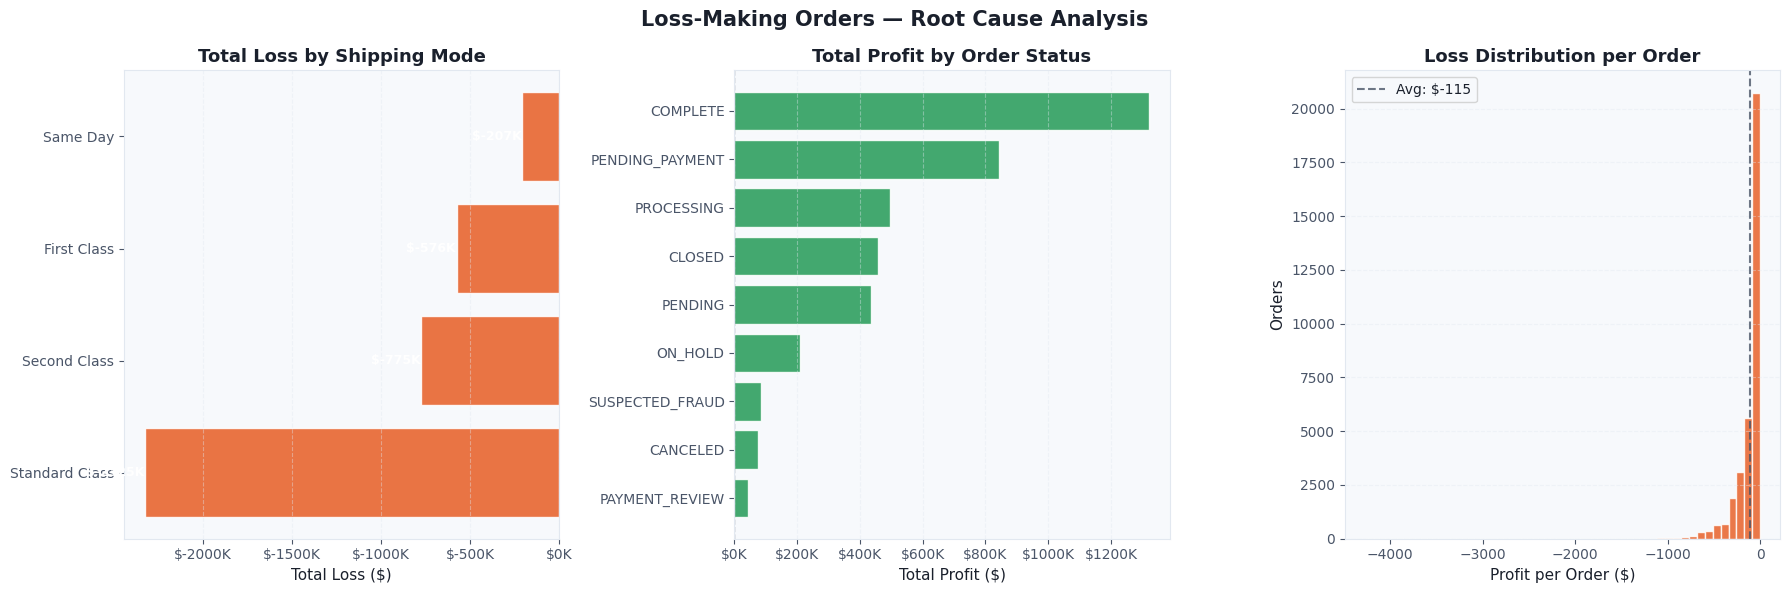

✅ Saved: loss_analysis.png

Loss by Order Status:
   Order Status  orders  total_profit  loss_rate
 PAYMENT_REVIEW    1893      43428.79       0.19
       CANCELED    3692      75345.63       0.19
SUSPECTED_FRAUD    4062      85136.71       0.20
        ON_HOLD    9803     208830.50       0.20
        PENDING   20224     435420.44       0.19
         CLOSED   19616     457981.09       0.18
     PROCESSING   21902     494825.87       0.18
PENDING_PAYMENT   39830     843854.47       0.19
       COMPLETE   59489    1321356.70       0.19


In [4]:
# ── 3. LOSS-MAKING ORDERS ANALYSIS ────────────────────────────────────────────
loss_orders   = df[df['Order Profit Per Order'] < 0].copy()
profit_orders = df[df['Order Profit Per Order'] >= 0].copy()

print(f"Loss-making orders: {len(loss_orders):,} ({len(loss_orders)/len(df):.1%})")
print(f"Total loss amount:  ${loss_orders['Order Profit Per Order'].sum():,.0f}")
print(f"Avg loss per order: ${loss_orders['Order Profit Per Order'].mean():,.2f}")
print(f"Max loss per order: ${loss_orders['Order Profit Per Order'].min():,.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Loss-Making Orders — Root Cause Analysis',
             fontsize=15, fontweight='bold', color=PALETTE['text'])

# Loss by shipping mode
loss_mode = loss_orders.groupby('Shipping Mode')['Order Profit Per Order'].agg(
    ['sum', 'count', 'mean']).reset_index()
loss_mode.columns = ['Shipping Mode', 'total_loss', 'orders', 'avg_loss']
loss_mode = loss_mode.sort_values('total_loss')

ax = axes[0]
bars = ax.barh(loss_mode['Shipping Mode'], loss_mode['total_loss'],
               color=PALETTE['secondary'], alpha=0.88, edgecolor='white')
ax.set_title('Total Loss by Shipping Mode')
ax.set_xlabel('Total Loss ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
for bar, val in zip(bars, loss_mode['total_loss']):
    ax.text(bar.get_width() - 5000, bar.get_y() + bar.get_height()/2,
            f'${val/1e3:.0f}K', va='center', ha='right',
            fontsize=9, color='white', fontweight='bold')
ax.grid(True, alpha=0.4, axis='x')

# Loss by order status
loss_status = df.groupby('Order Status').agg(
    total_profit = ('Order Profit Per Order', 'sum'),
    orders       = ('Order Id',               'count'),
    loss_orders  = ('Order Profit Per Order', lambda x: (x < 0).sum())
).reset_index()
loss_status['loss_rate'] = loss_status['loss_orders'] / loss_status['orders']
loss_status = loss_status.sort_values('total_profit')

ax = axes[1]
colors_st = [PALETTE['secondary'] if v < 0 else PALETTE['success']
             for v in loss_status['total_profit']]
ax.barh(loss_status['Order Status'], loss_status['total_profit'],
        color=colors_st, alpha=0.88, edgecolor='white')
ax.set_title('Total Profit by Order Status')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.axvline(0, color=PALETTE['neutral'], linewidth=1, linestyle='--', alpha=0.6)
ax.grid(True, alpha=0.4, axis='x')

# Loss distribution histogram
ax = axes[2]
ax.hist(loss_orders['Order Profit Per Order'], bins=50,
        color=PALETTE['secondary'], alpha=0.85, edgecolor='white')
ax.set_title('Loss Distribution per Order')
ax.set_xlabel('Profit per Order ($)')
ax.set_ylabel('Orders')
ax.axvline(loss_orders['Order Profit Per Order'].mean(), color=PALETTE['neutral'],
           linewidth=1.5, linestyle='--', alpha=0.8,
           label=f"Avg: ${loss_orders['Order Profit Per Order'].mean():.0f}")
ax.legend()
ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(IMG_PATH / 'loss_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: loss_analysis.png")
print(f"\nLoss by Order Status:")
print(loss_status[['Order Status','orders','total_profit',
                    'loss_rate']].sort_values('total_profit').to_string(index=False))

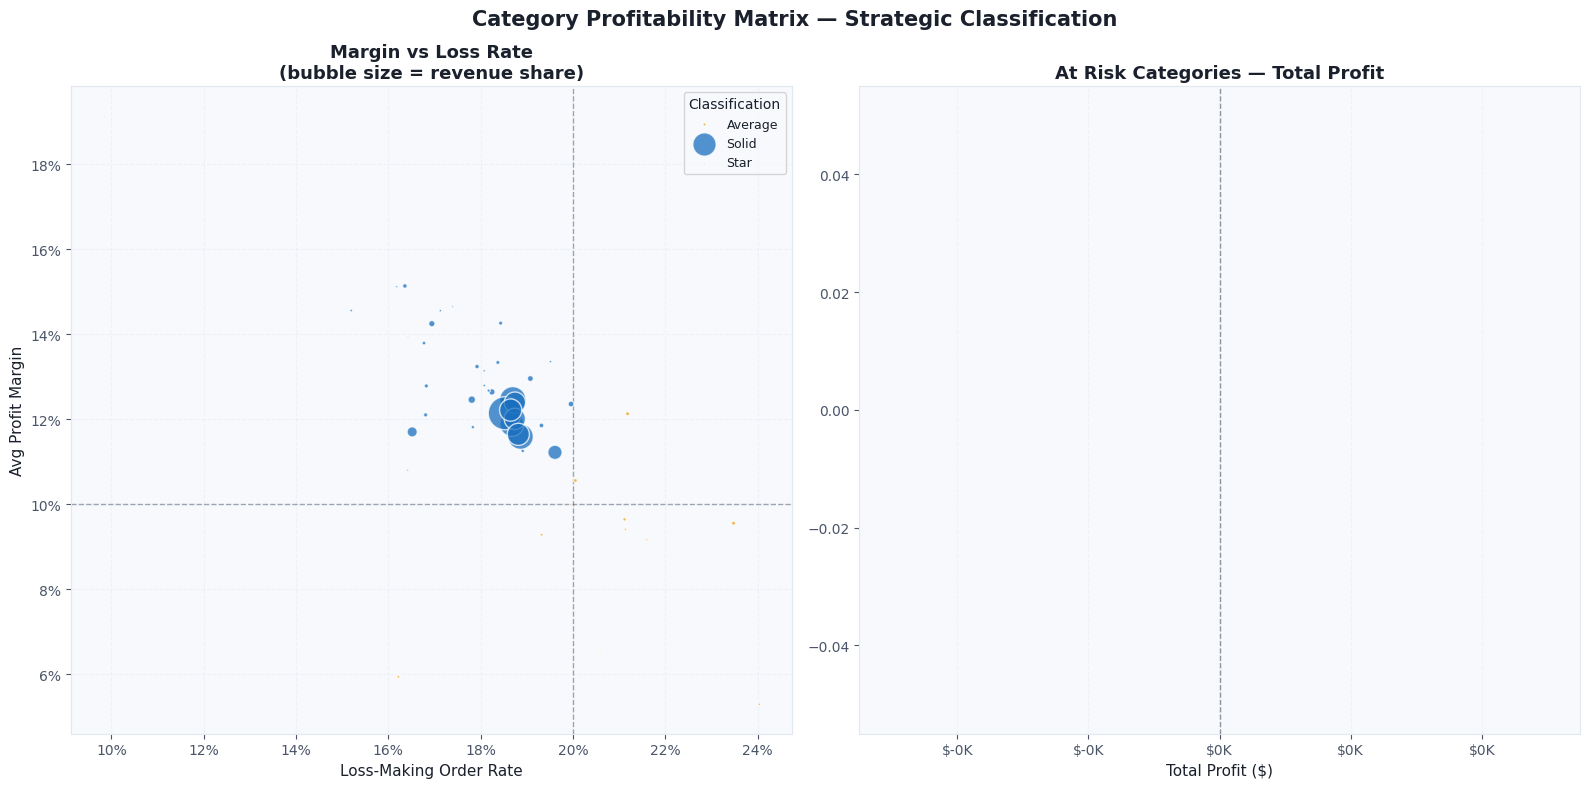

✅ Saved: category_matrix.png

Category Classification Summary:
                categories  total_revenue  total_profit  avg_margin
classification                                                     
Average                 12      690862.75      57319.85        0.09
Solid                   37    36080719.72    3907050.28        0.13
Star                     1       10369.39       1810.07        0.19


In [5]:
# ── 4. MARGIN OPTIMIZATION OPPORTUNITIES ──────────────────────────────────────
# Category-level deep dive
cat_analysis = df.groupby('Category Name').agg(
    orders       = ('Order Id',                'count'),
    revenue      = ('Sales',                   'sum'),
    total_profit = ('Order Profit Per Order',   'sum'),
    avg_margin   = ('Order Item Profit Ratio',  'mean'),
    loss_rate    = ('Order Profit Per Order',   lambda x: (x < 0).mean()),
    avg_discount = ('Order Item Discount Rate', 'mean'),
    late_rate    = ('is_late',                  'mean'),
).reset_index()

cat_analysis['profit_per_order'] = (cat_analysis['total_profit'] /
                                     cat_analysis['orders'])
cat_analysis['revenue_share']    = (cat_analysis['revenue'] /
                                     cat_analysis['revenue'].sum())

# Classify categories
def classify_category(row):
    if row['avg_margin'] > 0.15 and row['loss_rate'] < 0.15:
        return 'Star'           # high margin, low loss
    elif row['avg_margin'] > 0.10 and row['loss_rate'] < 0.20:
        return 'Solid'          # decent margin, acceptable loss
    elif row['avg_margin'] < 0.05 or row['loss_rate'] > 0.25:
        return 'At Risk'        # low margin or high loss rate
    else:
        return 'Average'

cat_analysis['classification'] = cat_analysis.apply(classify_category, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Category Profitability Matrix — Strategic Classification',
             fontsize=15, fontweight='bold', color=PALETTE['text'])

# Scatter: margin vs loss rate, sized by revenue
ax = axes[0]
class_colors = {
    'Star'    : PALETTE['success'],
    'Solid'   : PALETTE['primary'],
    'Average' : PALETTE['warning'],
    'At Risk' : PALETTE['secondary'],
}
for cls, grp in cat_analysis.groupby('classification'):
    ax.scatter(grp['loss_rate'], grp['avg_margin'],
               s=grp['revenue_share'] * 3000,
               c=class_colors[cls], alpha=0.75,
               edgecolors='white', linewidth=1,
               label=cls, zorder=3)

ax.axhline(0.10, color=PALETTE['neutral'], linewidth=1,
           linestyle='--', alpha=0.5)
ax.axvline(0.20, color=PALETTE['neutral'], linewidth=1,
           linestyle='--', alpha=0.5)
ax.set_title('Margin vs Loss Rate\n(bubble size = revenue share)')
ax.set_xlabel('Loss-Making Order Rate')
ax.set_ylabel('Avg Profit Margin')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Classification', fontsize=9)
ax.grid(True, alpha=0.4)

# Top opportunities — categories to fix
at_risk = cat_analysis[cat_analysis['classification'] == 'At Risk'].copy()
at_risk = at_risk.sort_values('total_profit')

ax = axes[1]
colors_ar = [PALETTE['secondary'] if v < 0 else PALETTE['warning']
             for v in at_risk['total_profit']]
bars = ax.barh(at_risk['Category Name'], at_risk['total_profit'],
               color=colors_ar, alpha=0.88, edgecolor='white')
ax.set_title('At Risk Categories — Total Profit')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.axvline(0, color=PALETTE['neutral'], linewidth=1, linestyle='--', alpha=0.6)
for bar, val in zip(bars, at_risk['total_profit']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val/1e3:.1f}K', va='center', fontsize=8, color=PALETTE['neutral'])
ax.grid(True, alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(IMG_PATH / 'category_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: category_matrix.png")
print(f"\nCategory Classification Summary:")
print(cat_analysis.groupby('classification').agg(
    categories   = ('Category Name',  'count'),
    total_revenue= ('revenue',         'sum'),
    total_profit = ('total_profit',    'sum'),
    avg_margin   = ('avg_margin',      'mean'),
).round(2).to_string())

In [6]:
# ── 4B. ADJUSTED CLASSIFICATION ───────────────────────────────────────────────
def classify_category_v2(row):
    if row['avg_margin'] >= 0.14 and row['loss_rate'] <= 0.18:
        return 'Star'              # top margin, low loss
    elif row['avg_margin'] >= 0.12 and row['loss_rate'] <= 0.19:
        return 'Solid'             # good margin, acceptable loss
    elif row['avg_margin'] < 0.10:
        return 'Underperformer'    # below average margin
    elif row['loss_rate'] > 0.21:
        return 'High Loss Risk'    # high proportion of losing orders
    else:
        return 'Average'

cat_analysis['classification'] = cat_analysis.apply(classify_category_v2, axis=1)

print("Category Classification Summary (adjusted):")
print(cat_analysis.groupby('classification').agg(
    categories   = ('Category Name',  'count'),
    total_revenue= ('revenue',         'sum'),
    total_profit = ('total_profit',    'sum'),
    avg_margin   = ('avg_margin',      'mean'),
    avg_loss_rate= ('loss_rate',       'mean'),
).round(3).to_string())

print(f"\nUnderperformers:")
under = cat_analysis[cat_analysis['classification'] == 'Underperformer']
print(under[['Category Name','orders','avg_margin','loss_rate',
             'total_profit']].sort_values('avg_margin').to_string(index=False))

print(f"\nHigh Loss Risk:")
hlr = cat_analysis[cat_analysis['classification'] == 'High Loss Risk']
print(hlr[['Category Name','orders','avg_margin','loss_rate',
           'total_profit']].sort_values('loss_rate', ascending=False).to_string(index=False))

print(f"\nStars:")
stars = cat_analysis[cat_analysis['classification'] == 'Star']
print(stars[['Category Name','orders','avg_margin','loss_rate',
             'total_profit']].sort_values('total_profit', ascending=False).to_string(index=False))

Category Classification Summary (adjusted):
                categories  total_revenue  total_profit  avg_margin  avg_loss_rate
classification                                                                    
Average                 13    13838214.15    1438075.73        0.12           0.19
High Loss Risk           1      107998.00      12406.07        0.12           0.21
Solid                   18    21783918.13    2404877.05        0.13           0.18
Star                     8      567754.40      74953.42        0.15           0.16
Underperformer          10      484067.17      35867.94        0.08           0.21

Underperformers:
     Category Name  orders  avg_margin  loss_rate  total_profit
    Men's Clothing     208        0.05       0.24       2006.04
 Strength Training     111        0.06       0.16        332.31
   As Seen on  TV!      68        0.06       0.21        714.43
            Books      405        0.08       0.19        883.01
       Video Games     838        0.0

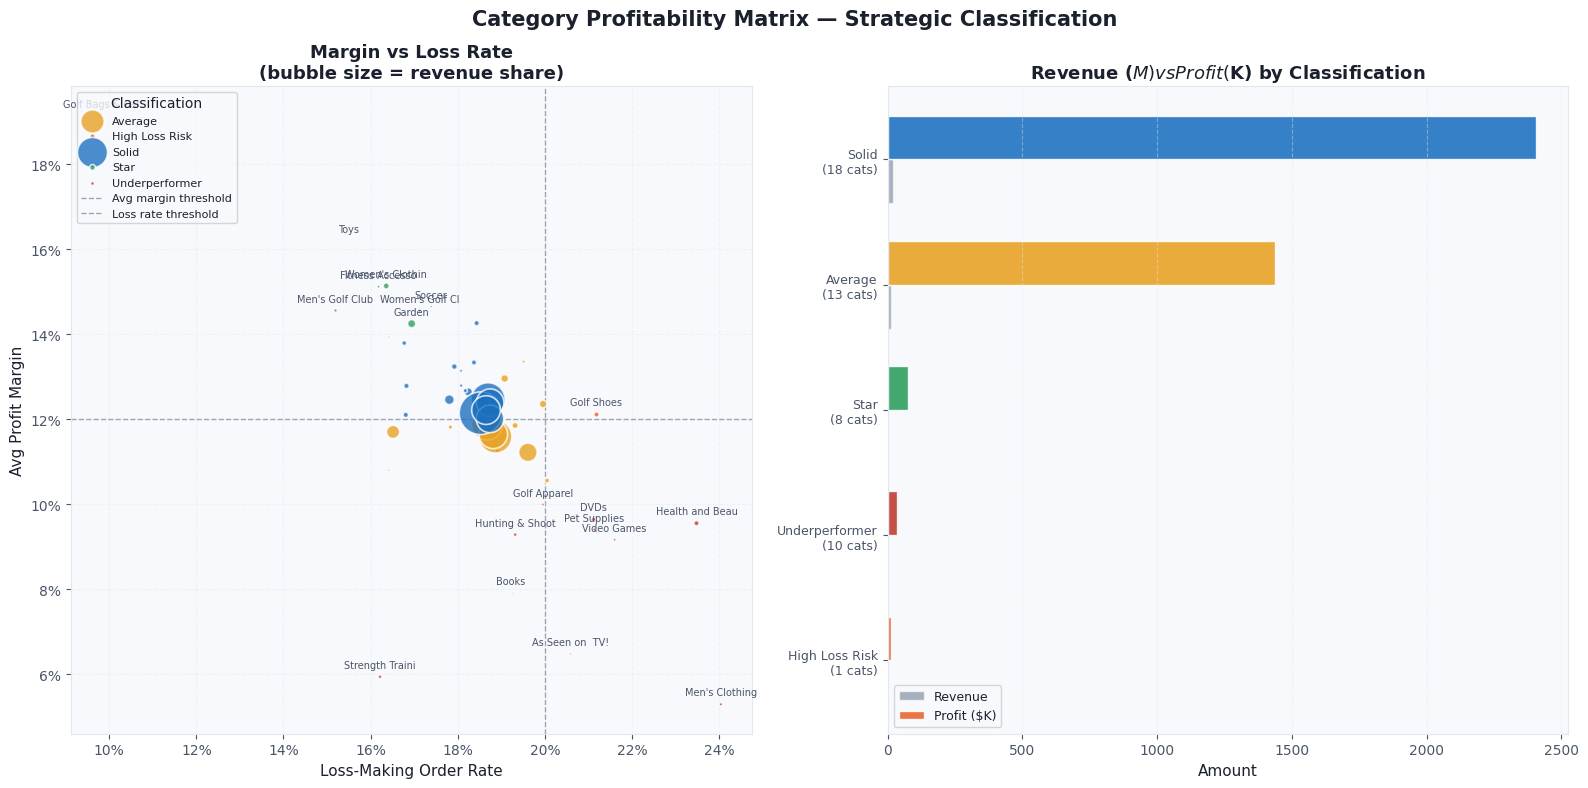

✅ Saved: category_matrix.png


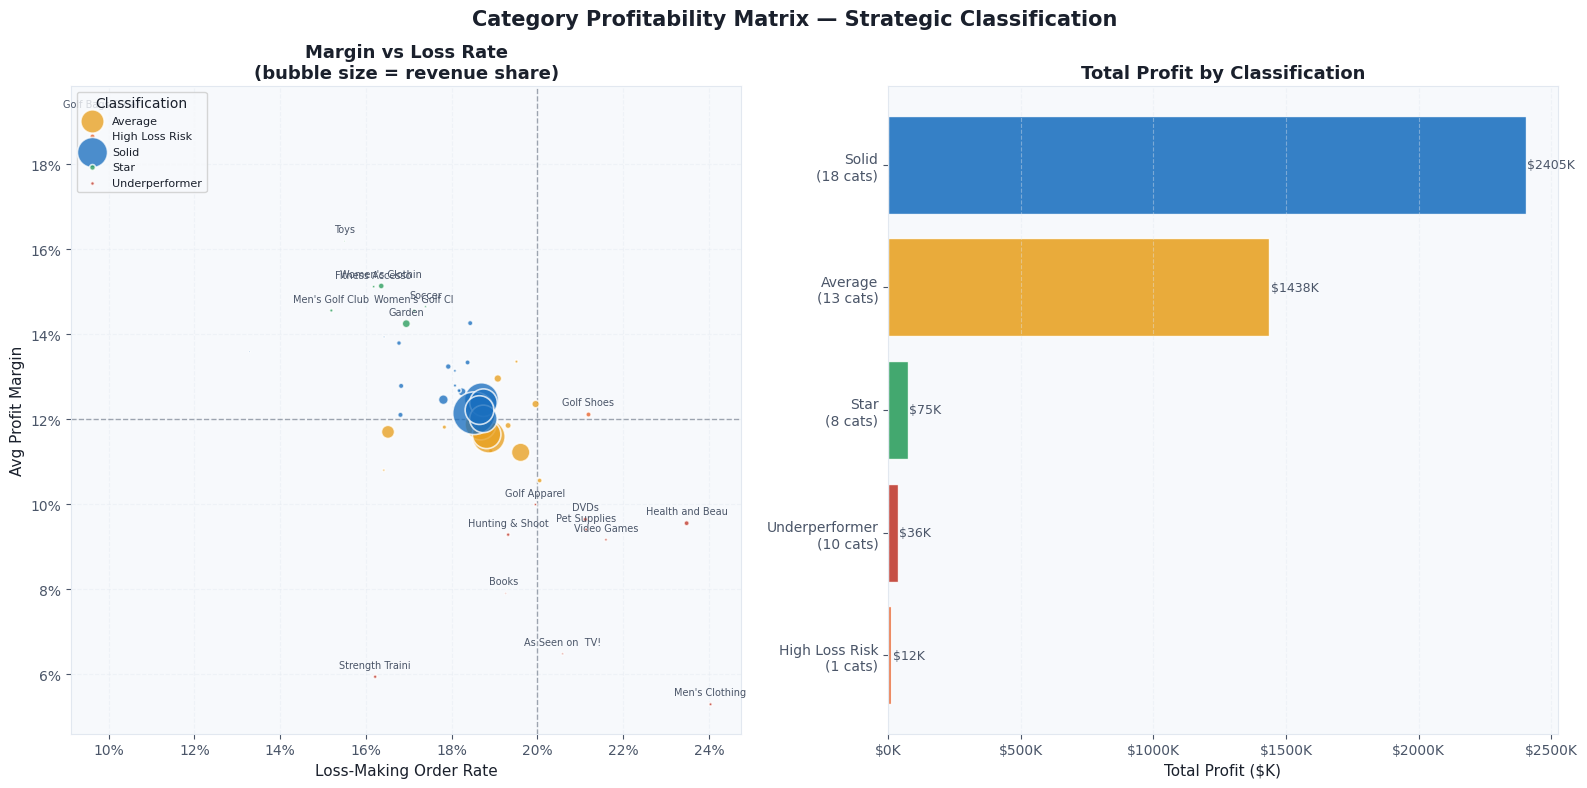

✅ Saved: category_matrix.png


In [9]:
# ── 5. PROFITABILITY MATRIX VISUALIZATION ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Category Profitability Matrix — Strategic Classification',
             fontsize=15, fontweight='bold', color=PALETTE['text'])

class_colors = {
    'Star'          : PALETTE['success'],
    'Solid'         : PALETTE['primary'],
    'Average'       : PALETTE['warning'],
    'High Loss Risk': PALETTE['secondary'],
    'Underperformer': '#C0392B',
}

# Scatter — margin vs loss rate
ax = axes[0]
for cls, grp in cat_analysis.groupby('classification'):
    ax.scatter(grp['loss_rate'], grp['avg_margin'],
               s=grp['revenue_share'] * 5000,
               c=class_colors[cls], alpha=0.78,
               edgecolors='white', linewidth=1.2,
               label=cls, zorder=3)

for _, row in cat_analysis.iterrows():
    if row['classification'] in ('Star', 'Underperformer', 'High Loss Risk'):
        ax.annotate(row['Category Name'][:15],
                    (row['loss_rate'], row['avg_margin']),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color=PALETTE['neutral'])

ax.axhline(0.12, color=PALETTE['neutral'], linewidth=1,
           linestyle='--', alpha=0.5)
ax.axvline(0.20, color=PALETTE['neutral'], linewidth=1,
           linestyle='--', alpha=0.5)
ax.set_title('Margin vs Loss Rate\n(bubble size = revenue share)')
ax.set_xlabel('Loss-Making Order Rate')
ax.set_ylabel('Avg Profit Margin')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Classification', fontsize=8, loc='upper left')
ax.grid(True, alpha=0.4)

# Total profit by classification
class_summary = cat_analysis.groupby('classification').agg(
    total_profit = ('total_profit', 'sum'),
    categories   = ('Category Name','count')
).reset_index().sort_values('total_profit', ascending=True)

ax = axes[1]
colors_cs = [class_colors[c] for c in class_summary['classification']]
bars = ax.barh(
    [f"{r['classification']}\n({r['categories']} cats)"
     for _, r in class_summary.iterrows()],
    class_summary['total_profit'] / 1e3,
    color=colors_cs, alpha=0.88, edgecolor='white'
)
for bar, val in zip(bars, class_summary['total_profit'] / 1e3):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}K', va='center', fontsize=9, color=PALETTE['neutral'])

ax.set_title('Total Profit by Classification')
ax.set_xlabel('Total Profit ($K)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.grid(True, alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(IMG_PATH / 'category_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: category_matrix.png")

In [10]:
# ── 6. BUSINESS RECOMMENDATIONS & SAVE ────────────────────────────────────────
# Quantify optimization opportunity
underperformers = cat_analysis[cat_analysis['classification'] == 'Underperformer']
stars           = cat_analysis[cat_analysis['classification'] == 'Star']
solid           = cat_analysis[cat_analysis['classification'] == 'Solid']

# If underperformers reached avg solid margin
avg_solid_margin  = solid['avg_margin'].mean()
uplift_potential  = underperformers.apply(
    lambda r: r['revenue'] * (avg_solid_margin - r['avg_margin']), axis=1
).sum()

# Fraud impact
fraud_orders  = df[df['Order Status'] == 'SUSPECTED_FRAUD']
fraud_revenue = fraud_orders['Sales'].sum()
fraud_profit  = fraud_orders['Order Profit Per Order'].sum()

print("=" * 65)
print("PROFITABILITY OPTIMIZATION — Business Recommendations")
print("=" * 65)
print(f"\n📊 Current State:")
print(f"   Total Revenue:         ${df['Sales'].sum():>12,.0f}")
print(f"   Total Profit:          ${df['Order Profit Per Order'].sum():>12,.0f}")
print(f"   Overall Margin:        {df['Order Profit Per Order'].sum()/df['Sales'].sum():>12.1%}")
print(f"   Loss-making orders:    {(df['Order Profit Per Order']<0).sum():>12,} ({(df['Order Profit Per Order']<0).mean():.1%})")

print(f"\n🎯 Optimization Opportunities:")
print(f"   1. Underperformer margin uplift to Solid avg ({avg_solid_margin:.1%}):")
print(f"      → Potential profit uplift: ${uplift_potential:>10,.0f}")
print(f"   2. Suspected fraud orders: {len(fraud_orders):,}")
print(f"      → Revenue at risk:       ${fraud_revenue:>10,.0f}")
print(f"      → Profit at risk:        ${fraud_profit:>10,.0f}")
print(f"   3. Delivery model net benefit: $9,220,624/year")
print(f"      (from Notebook 02)")

print(f"\n📋 Category Actions:")
print(f"   SCALE UP  → Stars: {', '.join(stars.nlargest(3,'total_profit')['Category Name'].tolist())}")
print(f"   REVIEW    → Underperformers: {', '.join(underperformers.nsmallest(3,'avg_margin')['Category Name'].tolist())}")
print(f"   MONITOR   → High Loss Risk: Golf Shoes (21% loss rate)")

total_opportunity = uplift_potential + fraud_profit
print(f"\n💡 Total identified profit opportunity: ${total_opportunity:,.0f}")
print("=" * 65)

# Save artifacts
cat_analysis.to_csv(DATA_PATH / 'category_profitability.csv', index=False)
loss_orders.to_csv(DATA_PATH / 'loss_making_orders.csv', index=False)

print("\n✅ Artifacts saved")
print(f"   category_profitability → {len(cat_analysis)} categories")
print(f"   loss_making_orders     → {len(loss_orders):,} orders")

PROFITABILITY OPTIMIZATION — Business Recommendations

📊 Current State:
   Total Revenue:         $  36,781,952
   Total Profit:          $   3,966,180
   Overall Margin:               10.8%
   Loss-making orders:          33,782 (18.7%)

🎯 Optimization Opportunities:
   1. Underperformer margin uplift to Solid avg (12.9%):
      → Potential profit uplift: $    20,942
   2. Suspected fraud orders: 4,062
      → Revenue at risk:       $   825,935
      → Profit at risk:        $    85,137
   3. Delivery model net benefit: $9,220,624/year
      (from Notebook 02)

📋 Category Actions:
   SCALE UP  → Stars: Garden, Women's Clothing, Men's Golf Clubs
   REVIEW    → Underperformers: Men's Clothing, Strength Training, As Seen on  TV!
   MONITOR   → High Loss Risk: Golf Shoes (21% loss rate)

💡 Total identified profit opportunity: $106,079

✅ Artifacts saved
   category_profitability → 50 categories
   loss_making_orders     → 33,782 orders
